Data source : https://www.kaggle.com/c/home-credit-default-risk/data

But notebook : Feature Engineering / Reduction

- utiliser les donnes agrégées précédemment
- réduire le dataframe (optimisation de futurs temps de calcul / temps de modélisation) tout en ayant le moins de données manquantes dans les features restantes
   - verification des types et choix de types plus avantageux en poids si possible
   - entrainement sur différents modèles et extraction des features notables via SHAPE ou autre (knn most important features)
   - éviter de "créer" des informations ex-nihilo avec de l'inputing : favoriser la sélection / suppression en préservant au mieux l'intégrité des données

# Imports

## libraries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import numpy as np
import pandas as pd
import inspect

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# import utils from parent directory
import sys
from pathlib import Path
parent_dir = str(Path().resolve().parents[1])
sys.path.insert(0, parent_dir)

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

In [4]:
import gc
import time
from contextlib import contextmanager
import re

In [5]:
# https://numpy.org/doc/stable/release/2.0.0-notes.html#representation-of-numpy-scalars-changed
np.set_printoptions(legacy='1.21')

In [6]:
import mlflow
import mlflow.lightgbm
import mlflow.xgboost
import mlflow.sklearn

from mlflow import MlflowClient
from mlflow.models.signature import infer_signature
from pprint import pprint

In [7]:
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn import model_selection
import xgboost as xgb


from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, fbeta_score, make_scorer

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


import shap

## data

In [8]:
csv_path_output = '../data/output/'
file_name = 'df_cleaned.csv'

df = pd.read_csv(f'{csv_path_output + file_name}', encoding='ISO-8859-1')
df.drop(df.filter(regex="Unname"),axis=1, inplace=True)

In [9]:
df.shape

(74878, 38)

In [10]:
df.head()

,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_EMPLOYED,INSTAL_DPD_MEAN,CODE_GENDER,PAYMENT_RATE,DAYS_EMPLOYED_PERC,DAYS_BIRTH,PREV_CNT_PAYMENT_MEAN,AMT_GOODS_PRICE,...,INSTAL_PAYMENT_PERC_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,PREV_APP_CREDIT_PERC_MIN,INSTAL_AMT_PAYMENT_MIN,BURO_CREDIT_ACTIVE_Closed_MEAN,DAYS_REGISTRATION,APPROVED_AMT_ANNUITY_MAX,INSTAL_AMT_PAYMENT_MEAN,ACTIVE_DAYS_CREDIT_ENDDATE_MEAN,TARGET
0,0.262949,0.139376,-637.0,0.000000,0,0.060749,0.067329,-9461,24.000,351000.0,...,1.000000,-315.42105,1.000000,9251.775,0.750000,-3648.0,9251.775,11559.247,780.00,1.0
1,0.715042,0.176653,-2717.0,3.527027,1,0.072732,0.202173,-13439,17.000,67500.0,...,0.837838,-1297.58100,0.909881,3.960,0.428571,-311.0,14480.460,8391.646,381.75,0.0
2,0.706428,0.556727,-7804.0,0.000000,1,0.050000,0.440456,-17718,18.000,157500.0,...,1.000000,-142.42857,0.863260,6765.975,0.000000,-8751.0,6765.975,6765.975,940.00,0.0
3,0.457143,0.358951,-4306.0,0.000000,1,0.065367,0.386327,-11146,21.000,450000.0,...,1.000000,-1105.87500,0.906651,23531.176,0.333333,-114.0,42778.844,119294.590,899.00,0.0
4,0.651406,0.461482,-3494.0,0.000000,1,0.049220,0.180718,-19334,8.625,225000.0,...,1.000000,-730.66670,0.949873,9035.685,0.666667,-2419.0,9035.685,11820.645,1409.00,0.0


# Explo

## Valeurs manquantes

In [11]:
# https://medium.com/@kavyasree42/how-to-handle-missing-data-in-python-simple-to-advanced-techniques-machine-learning-brain-ffae3c1a694f

In [12]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))
    
# Function to calculate missing values by column
def missing_values_table(df):
    # Taux de valeurs manquantes :
    print("Taux de valeurs manquantes dans le df avant imputation :" , round(df.isna().mean().mean(),4))
    # Total missing values
    mis_val = df.isnull().sum()
    
    # Percentage of missing values
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    
    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    
    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    
    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    
    # Print some summary information
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
           "There are " + str(mis_val_table_ren_columns.shape[0]) +
           " columns that have missing values.")
    
    # Return the dataframe with missing information
    return mis_val_table_ren_columns

In [13]:
#  Statistiques sur les valeurs manquantes :
missing_values = missing_values_table(df)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Séparation du jeu de données en jeu de  training/validation et jeu de test
train_df = df[df['TARGET'].notnull()] # partie du jeu de données qui contient une target
test_df = df[df['TARGET'].isnull()] # partie du jeu de données qui n'a pas de target
print(train_df.shape, test_df.shape)
train_df["TARGET"].value_counts()/train_df.shape[0]

# Taux de valeurs manquantes :
print("Taux de valeurs manquantes dans jeu de train avant imputation :" , round(train_df.isna().mean().mean(),4))
print("Taux de valeurs manquantes dans jeu de test avant imputation :" , round(test_df.isna().mean().mean(),4))

Taux de valeurs manquantes dans le df avant imputation : 0.0
Your selected dataframe has 38 columns.
There are 0 columns that have missing values.
(74878, 38) (0, 38)
Taux de valeurs manquantes dans jeu de train avant imputation : 0.0
Taux de valeurs manquantes dans jeu de test avant imputation : nan


# Typage

In [14]:
df.head()

,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_EMPLOYED,INSTAL_DPD_MEAN,CODE_GENDER,PAYMENT_RATE,DAYS_EMPLOYED_PERC,DAYS_BIRTH,PREV_CNT_PAYMENT_MEAN,AMT_GOODS_PRICE,...,INSTAL_PAYMENT_PERC_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,PREV_APP_CREDIT_PERC_MIN,INSTAL_AMT_PAYMENT_MIN,BURO_CREDIT_ACTIVE_Closed_MEAN,DAYS_REGISTRATION,APPROVED_AMT_ANNUITY_MAX,INSTAL_AMT_PAYMENT_MEAN,ACTIVE_DAYS_CREDIT_ENDDATE_MEAN,TARGET
0,0.262949,0.139376,-637.0,0.000000,0,0.060749,0.067329,-9461,24.000,351000.0,...,1.000000,-315.42105,1.000000,9251.775,0.750000,-3648.0,9251.775,11559.247,780.00,1.0
1,0.715042,0.176653,-2717.0,3.527027,1,0.072732,0.202173,-13439,17.000,67500.0,...,0.837838,-1297.58100,0.909881,3.960,0.428571,-311.0,14480.460,8391.646,381.75,0.0
2,0.706428,0.556727,-7804.0,0.000000,1,0.050000,0.440456,-17718,18.000,157500.0,...,1.000000,-142.42857,0.863260,6765.975,0.000000,-8751.0,6765.975,6765.975,940.00,0.0
3,0.457143,0.358951,-4306.0,0.000000,1,0.065367,0.386327,-11146,21.000,450000.0,...,1.000000,-1105.87500,0.906651,23531.176,0.333333,-114.0,42778.844,119294.590,899.00,0.0
4,0.651406,0.461482,-3494.0,0.000000,1,0.049220,0.180718,-19334,8.625,225000.0,...,1.000000,-730.66670,0.949873,9035.685,0.666667,-2419.0,9035.685,11820.645,1409.00,0.0


In [15]:
df.dtypes

EXT_SOURCE_2                           float64
EXT_SOURCE_3                           float64
DAYS_EMPLOYED                          float64
INSTAL_DPD_MEAN                        float64
CODE_GENDER                              int64
PAYMENT_RATE                           float64
DAYS_EMPLOYED_PERC                     float64
DAYS_BIRTH                               int64
PREV_CNT_PAYMENT_MEAN                  float64
AMT_GOODS_PRICE                        float64
AMT_ANNUITY                            float64
ANNUITY_INCOME_PERC                    float64
INSTAL_AMT_PAYMENT_SUM                 float64
APPROVED_AMT_DOWN_PAYMENT_MAX          float64
BURO_AMT_CREDIT_SUM_DEBT_MEAN          float64
NAME_EDUCATION_TYPE_Highereducation      int64
AMT_CREDIT                             float64
ACTIVE_DAYS_CREDIT_MAX                 float64
BURO_DAYS_CREDIT_MEAN                  float64
PREV_APP_CREDIT_PERC_MEAN              float64
INSTAL_PAYMENT_DIFF_MEAN               float64
POS_MONTHS_BA

In [16]:
# Vérification des dtypes actuels
print("Dtypes initiaux :")
print(df.dtypes.value_counts())
print("\nInfos avant conversion :")
print(df.info())
df_memory_usage_gb = df.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df_memory_usage_gb} Gb')

# Analyse de la distribution des données
for column in df.columns:
    if df[column].dtype == 'int64':
        min_val, max_val = df[column].min(), df[column].max()
        if min_val >= np.iinfo(np.int8).min and max_val <= np.iinfo(np.int8).max:
            df[column] = df[column].astype(np.int8)
        elif min_val >= np.iinfo(np.int16).min and max_val <= np.iinfo(np.int16).max:
            df[column] = df[column].astype(np.int16)
        elif min_val >= np.iinfo(np.int32).min and max_val <= np.iinfo(np.int32).max:
            df[column] = df[column].astype(np.int32)
    elif df[column].dtype == 'float64':
        df[column] = df[column].astype(np.float32)

# Vérification des dtypes après conversion
print("\nDtypes après conversion :")
print(df.dtypes.value_counts())
print("\nInfos sur le DataFrame :")
print(df.info())
df_memory_usage_gb = df.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df_memory_usage_gb} Gb')

Dtypes initiaux :
float64    34
int64       4
dtype: int64

Infos avant conversion :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74878 entries, 0 to 74877
Data columns (total 38 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   EXT_SOURCE_2                         74878 non-null  float64
 1   EXT_SOURCE_3                         74878 non-null  float64
 2   DAYS_EMPLOYED                        74878 non-null  float64
 3   INSTAL_DPD_MEAN                      74878 non-null  float64
 4   CODE_GENDER                          74878 non-null  int64  
 5   PAYMENT_RATE                         74878 non-null  float64
 6   DAYS_EMPLOYED_PERC                   74878 non-null  float64
 7   DAYS_BIRTH                           74878 non-null  int64  
 8   PREV_CNT_PAYMENT_MEAN                74878 non-null  float64
 9   AMT_GOODS_PRICE                      74878 non-null  float64
 10  AMT_ANNUI

In [17]:
df['TARGET'].value_counts(dropna=False)

0.0    69239
1.0     5639
Name: TARGET, dtype: int64

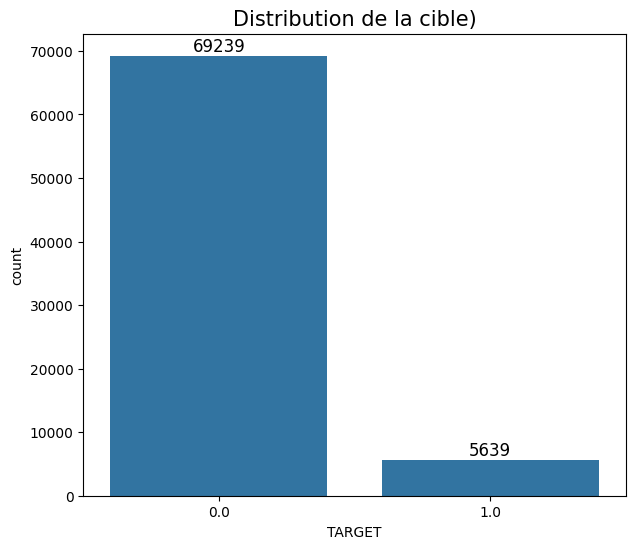

In [18]:
fig,ax=plt.subplots(figsize=(7,6))
plt.title("Distribution de la cible)", fontsize=15)
sns.countplot(x='TARGET', data=df)
for container in ax.containers:
    ax.bar_label(container,size=12,fmt='%.0f')
plt.show()

In [19]:
# Séparer les données en X_train et X_test
X_train = df[df['TARGET'].notna()]
X_test = df[df['TARGET'].isna()]

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)

Dimensions de X_train : (74878, 38)
Dimensions de X_test : (0, 38)


In [20]:
X_train['TARGET'].value_counts(dropna=False)

0.0    69239
1.0     5639
Name: TARGET, dtype: int64

In [21]:
# Vérifier les valeurs manquantes dans X_train
missing_values = X_train.isna().sum()

# Afficher les valeurs manquantes par colonne
print("Valeurs manquantes dans X_train :")
print(missing_values.sum())

Valeurs manquantes dans X_train :
0


In [22]:
# Calculer le pourcentage de valeurs manquantes par colonne
missing_percentages = X_train.isna().mean() * 100

# Créer un DataFrame pour afficher les résultats
missing_table = pd.DataFrame({
    'Feature': missing_percentages.index,
    'Missing Percentage': missing_percentages.values
}).sort_values(by='Missing Percentage', ascending=False)

# Ajouter une ligne pour le total
total_missing_percentage = missing_percentages.mean()
missing_table = pd.concat([missing_table, pd.DataFrame({
    'Feature': ['Total'],
    'Missing Percentage': [total_missing_percentage]
})], ignore_index=True)

# Afficher le tableau
pd.set_option('display.max_rows', None)
print("Pourcentage de valeurs manquantes par feature :")
print(missing_table)

Pourcentage de valeurs manquantes par feature :
                                Feature  Missing Percentage
0                          EXT_SOURCE_2                 0.0
1              INSTAL_PAYMENT_PERC_MEAN                 0.0
2               POS_MONTHS_BALANCE_SIZE                 0.0
3             APPROVED_CNT_PAYMENT_MEAN                 0.0
4                       DAYS_ID_PUBLISH                 0.0
5             APPROVED_AMT_ANNUITY_MEAN                 0.0
6        ACTIVE_DAYS_CREDIT_ENDDATE_MAX                 0.0
7                  BURO_DAYS_CREDIT_MAX                 0.0
8                        TOTALAREA_MODE                 0.0
9        INSTAL_DAYS_ENTRY_PAYMENT_MEAN                 0.0
10                         EXT_SOURCE_3                 0.0
11             PREV_APP_CREDIT_PERC_MIN                 0.0
12               INSTAL_AMT_PAYMENT_MIN                 0.0
13       BURO_CREDIT_ACTIVE_Closed_MEAN                 0.0
14                    DAYS_REGISTRATION             

In [23]:
def missing_values_count(df):
    # Calculer le pourcentage de valeurs manquantes par colonne
    missing_percentages = df.isna().mean() * 100
    
    # Créer des bins pour les pourcentages de valeurs manquantes
    bins = [0, 0.01, 20, 40, 60, 100]  # 0%, 0-20%, 20-40%, 40-60%, 60-100%
    labels = ['0%', '0-20%', '20-40%', '40-60%', '60-100%']
    
    # Classer les caractéristiques dans les bins
    missing_bins = pd.cut(missing_percentages, bins=bins, labels=labels, right=False)
    
    # Compter le nombre de variables par bin
    bin_counts = missing_bins.value_counts().sort_index()
    
    # Calculer le pourcentage de variables dans chaque bin par rapport au total
    total_variables = len(missing_percentages)
    bin_percentages = (bin_counts / total_variables) * 100
    
    # Créer un DataFrame pour afficher les résultats
    bin_summary = pd.DataFrame({
        'Number of Variables': bin_counts,
        'Percentage of Total': bin_percentages
    })
    
    # Afficher le nombre de variables par bin et leur pourcentage par rapport au total
    print("Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :")
    print(bin_summary)

In [24]:
missing_values_count(X_train)

Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :
         Number of Variables  Percentage of Total
0%                        38                100.0
0-20%                      0                  0.0
20-40%                     0                  0.0
40-60%                     0                  0.0
60-100%                    0                  0.0


# Modélisations + MLflow

In [25]:
# Séparer les caractéristiques et la cible
X = X_train.drop(columns=['TARGET'])
y = X_train['TARGET']

# Remplacer les valeurs infinies par NaN ___ "XGBoostError : Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`"
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remplacer les NaN par la moyenne de la colonne
#X.fillna(X.mean(), inplace=True)

In [26]:
X.head()

,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_EMPLOYED,INSTAL_DPD_MEAN,CODE_GENDER,PAYMENT_RATE,DAYS_EMPLOYED_PERC,DAYS_BIRTH,PREV_CNT_PAYMENT_MEAN,AMT_GOODS_PRICE,...,TOTALAREA_MODE,INSTAL_PAYMENT_PERC_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,PREV_APP_CREDIT_PERC_MIN,INSTAL_AMT_PAYMENT_MIN,BURO_CREDIT_ACTIVE_Closed_MEAN,DAYS_REGISTRATION,APPROVED_AMT_ANNUITY_MAX,INSTAL_AMT_PAYMENT_MEAN,ACTIVE_DAYS_CREDIT_ENDDATE_MEAN
0,0.262949,0.139376,-637.0,0.000000,0,0.060749,0.067329,-9461,24.000,351000.0,...,0.0149,1.000000,-315.421051,1.000000,9251.775391,0.750000,-3648.0,9251.775391,11559.247070,780.00
1,0.715042,0.176653,-2717.0,3.527027,1,0.072732,0.202173,-13439,17.000,67500.0,...,0.0612,0.837838,-1297.581055,0.909881,3.960000,0.428571,-311.0,14480.459961,8391.646484,381.75
2,0.706428,0.556727,-7804.0,0.000000,1,0.050000,0.440456,-17718,18.000,157500.0,...,0.0238,1.000000,-142.428574,0.863260,6765.975098,0.000000,-8751.0,6765.975098,6765.975098,940.00
3,0.457143,0.358951,-4306.0,0.000000,1,0.065367,0.386327,-11146,21.000,450000.0,...,0.0696,1.000000,-1105.875000,0.906651,23531.175781,0.333333,-114.0,42778.843750,119294.593750,899.00
4,0.651406,0.461482,-3494.0,0.000000,1,0.049220,0.180718,-19334,8.625,225000.0,...,0.0533,1.000000,-730.666687,0.949873,9035.684570,0.666667,-2419.0,9035.684570,11820.644531,1409.00


In [27]:
y.head()

0    1.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: TARGET, dtype: float32

In [28]:
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## test MLflow

In [29]:
# Définir les paramètres pour chaque modèle
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

lgb_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

rf_params = {
    'n_estimators': 100,
    'max_depth': 3,
    'random_state': 42
}

In [30]:
# Fonction pour entraîner et suivre un modèle avec MLflow
def train_and_log_model(model_name, model, params):
    with mlflow.start_run():
        # Entraîner le modèle
        model.fit(X_train, y_train)

        # Prédire les probabilités pour la classe positive
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculer le score ROC-AUC
        auc_roc = roc_auc_score(y_test, y_pred_proba)

        # Journaliser les paramètres et les métriques
        mlflow.log_params(params)
        mlflow.log_metric("auc_roc", auc_roc)

        # Prendre un exemple d'entrée pour la signature du modèle
        input_example = X_train.head(1)

        # Journaliser le modèle avec un exemple d'entrée
        if model_name == "XGBoost":
            mlflow.xgboost.log_model(model, "model", input_example=input_example)
        elif model_name == "LightGBM":
            mlflow.lightgbm.log_model(model, "model", input_example=input_example)
        elif model_name == "RandomForest":
            mlflow.sklearn.log_model(model, "model", input_example=input_example)

        print(f"{model_name} - AUC-ROC: {auc_roc}")


In [31]:
# Entraîner et suivre chaque modèle
train_and_log_model("XGBoost", xgb.XGBClassifier(**xgb_params), xgb_params)

XGBoost - AUC-ROC: 0.7539141288985675


In [32]:
train_and_log_model("LightGBM", lgb.LGBMClassifier(**lgb_params), lgb_params)

[LightGBM] [Info] Number of positive: 3913, number of negative: 48501
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8727
[LightGBM] [Info] Number of data points in the train set: 52414, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.074656 -> initscore=-2.517280
[LightGBM] [Info] Start training from score -2.517280
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM - AUC-ROC: 0.75615922517058


In [33]:
train_and_log_model("RandomForest", RandomForestClassifier(**rf_params), rf_params)

RandomForest - AUC-ROC: 0.7172751595891443


In [41]:
# Initialiser MLflow
mlflow.set_experiment("Model_Comparison")

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

def train_model(model, param_dist, X_train, y_train, X_test, y_test, model_name):
    with mlflow.start_run():
        # RandomizedSearchCV pour le tuning des hyperparamètres
        random_search = RandomizedSearchCV(
            model, param_distributions=param_dist, n_iter=10, cv=5, scoring='precision', random_state=42
        )
        random_search.fit(X_train, y_train)

        # Enregistrer les paramètres et les métriques avec MLflow
        mlflow.log_params(random_search.best_params_)
        metrics = evaluate_model(random_search.best_estimator_, X_test, y_test)
        mlflow.log_metrics(metrics)

        # Enregistrer le modèle avec un exemple d'entrée
        input_example = X_train[:1]  # Utiliser la première ligne de X_train comme exemple d'entrée
        mlflow.sklearn.log_model(
            random_search.best_estimator_, model_name, input_example=input_example
        )

        return random_search.best_estimator_, metrics


In [42]:
# Définir les modèles et les espaces de recherche des hyperparamètres
models = {
    "XGBoost": {
        "model": XGBClassifier(),
        "param_dist": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
        }
    },
    "LightGBM": {
        "model": LGBMClassifier(),
        "param_dist": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            "num_leaves": [20, 30, 40, 50], 
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(),
        "param_dist": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "min_samples_split": [2, 5, 10],
        }
    }
}

In [ ]:
# Entraîner et évaluer les modèles
for model_name, model_info in models.items():
    print(f"Training {model_name}...")
    best_model, metrics = train_model(
        model_info["model"], model_info["param_dist"], X_train, y_train, X_test, y_test, model_name
    )
    print(f"{model_name} metrics: {metrics}")

Training XGBoost...
XGBoost metrics: {'accuracy': 0.9229878917378918, 'precision': 0.375, 'recall': 0.0034762456546929316, 'f1': 0.006888633754305396}
Training LightGBM...
[LightGBM] [Info] Number of positive: 3131, number of negative: 38800
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005315 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8709
[LightGBM] [Info] Number of data points in the train set: 41931, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.074670 -> initscore=-2.517068
[LightGBM] [Info] Start training from score -2.517068
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

In [38]:
# afficher mlflow dans terminal : mlflow ui
# check mlflow dans dossier actuel :
# mlflow ui --backend-store-uri file://$(pwd)/mlruns

In [40]:

# Définir l'URI de suivi
mlflow.set_tracking_uri("file:////home/mijka/code/openclassrooms/projets/projet_7/notebooks/mlruns")

# Créer une nouvelle expérience
experiment_id = mlflow.create_experiment("Test Experiment")

# Lancer une nouvelle exécution
with mlflow.start_run(experiment_id=experiment_id):
    mlflow.log_param("param1", 5)
    mlflow.log_metric("metric1", 0.89)